# 1. 📚 Importar librerias

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# 2. 📊 Cargar csv/df

In [ ]:
#df = pd.read_csv('../data/raw/2023-03-08 Precios Casas RM.csv')
#df = pd.read_csv('../data/raw/2023-07-18 Propiedades Web Scrape.csv', chunksize=1000) 
# Importamos el archivo csv a la variable df
df = pd.DataFrame()
data = str
for chunk in pd.read_csv('../data/raw/2023-07-18 Propiedades Web Scrape.csv', chunksize = 1000):
    data += chunk
#df = df.copy()
#df.head()

NameError: name 'data' is not defined

# 3. 🔬 EDA
Comenzamos un EDA

In [3]:
display(df.info(),df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   9291 non-null   int64  
 1   Price_UF    9291 non-null   float64
 2   Price_USD   9291 non-null   float64
 3   Comuna      9291 non-null   object 
 4   Ubicacion   9291 non-null   object 
 5   Dorms       9202 non-null   float64
 6   Baths       9138 non-null   float64
 7   Built Area  9013 non-null   float64
 8   Total Area  9057 non-null   float64
 9   Parking     6371 non-null   float64
 10  id          9291 non-null   int64  
 11  Realtor     8125 non-null   object 
dtypes: float64(7), int64(2), object(3)
memory usage: 871.2+ KB


None

(9291, 12)

El dataset contiene 9291 entradas, sin embargo hay variables que contienen menos datos, lo que nos indica que hay valores nulos

In [4]:
df.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
id               0
Realtor       1166
dtype: int64

In [5]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor', 'Dorms']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( df[col].isnull().sum() / df.shape[0] ) * 100 ).round(2) }%')

% de datos que son nulos para "Baths": 1.65%
% de datos que son nulos para "Built Area": 2.99%
% de datos que son nulos para "Total Area": 2.52%
% de datos que son nulos para "Parking": 31.43%
% de datos que son nulos para "Realtor": 12.55%
% de datos que son nulos para "Dorms": 0.96%


In [6]:
df.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='object')

In [7]:
df.describe().style.format('{:,.2f}')

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"9,291.00","9,291.00","9,291.00","9,202.00","9,138.00","9,013.00","9,057.00","6,371.00","9,291.00"
mean,"392,513,379.71","10,879.28","478,674.86",4.03,2.75,"6,091.60",890.98,2.68,"14,111,574.63"
std,"403,651,502.95","11,187.99","492,257.92",1.66,1.48,"527,436.68","11,291.40",2.22,"4,187,239.01"
min,"37,000,000.00","1,026.00","45,122.00",1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"128,206,726.50","3,553.50","156,350.00",3.00,2.00,90.00,134.00,1.00,"11,087,459.00"
50%,"234,513,500.00","6,500.00","285,992.00",4.00,3.00,131.00,230.00,2.00,"14,436,826.00"
75%,"526,753,400.00","14,600.00","642,382.00",5.00,3.00,209.00,480.00,3.00,"17,844,280.00"
max,"4,870,665,000.00","135,000.00","5,939,835.00",35.00,29.00,"50,000,000.00","720,000.00",26.00,"20,161,463.00"


# 4. ☣️ Limpieza datos 

In [8]:
df[df.duplicated()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor


In [9]:
df_clean = df.dropna(subset=['Baths', 'Built Area', 'Total Area', 'Dorms']).copy()
df_clean['Parking'] = df_clean['Parking'].fillna(0)
df_clean['Realtor'] = df_clean['Realtor'].fillna('Desconocido')
df_clean = df_clean[df_clean['Price_UF'] > 0]

df_clean.drop(columns=['Price_CLP','Price_USD','id','Ubicacion'], inplace=True)

df_clean = df_clean.drop_duplicates()

df_clean.reset_index(drop=True, inplace=True)

In [10]:
display(df_clean[df_clean.duplicated()])

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor


np.float64(0.237339941394813)

np.float64(2.512754187747317)

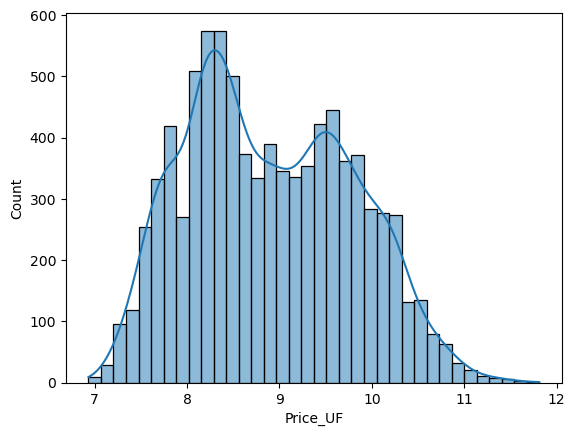

In [11]:
sns.histplot(np.log(df_clean['Price_UF']), kde=True)

display(np.log(df_clean['Price_UF']).skew(),df_clean['Price_UF'].skew())

# 5. 🕶️ Analisis

Text(0, 0.5, 'Casas')

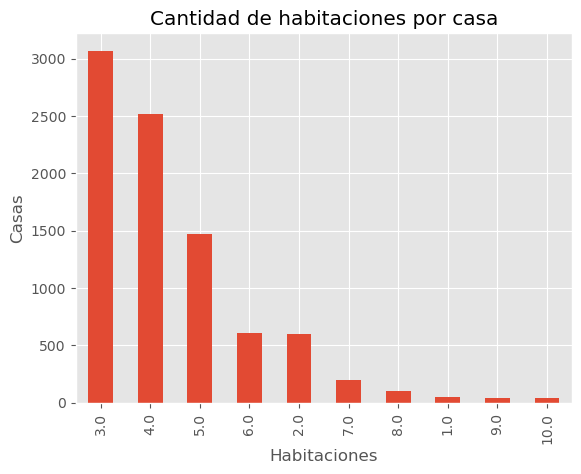

In [12]:
plt.style.use('ggplot') #fivethirtyeight
ax = df_clean['Dorms'].value_counts().head(10)\
    .plot(kind='bar', 
          title='Cantidad de habitaciones por casa')
ax.set_xlabel('Habitaciones')
ax.set_ylabel('Casas')

Text(0, 0.5, 'Comuna')

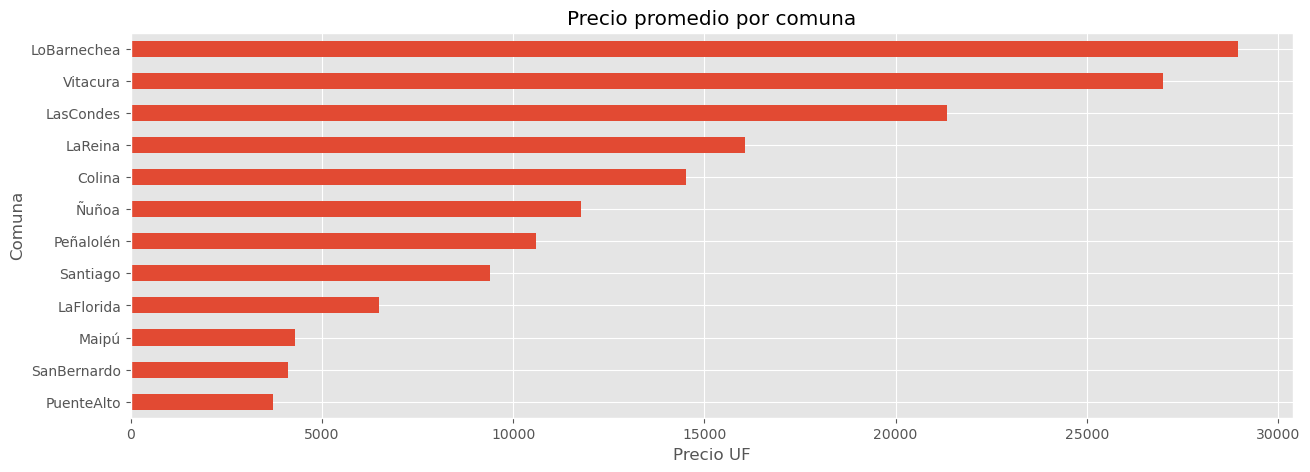

In [13]:
bx = df_clean.groupby('Comuna')['Price_UF'] \
    .agg(['mean', 'count']) \
    .query('count >= 250') \
    .sort_values('mean')['mean'] \
    .plot(kind='barh',
          figsize=(15,5),
          title='Precio promedio por comuna')
bx.set_xlabel('Precio UF')
bx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

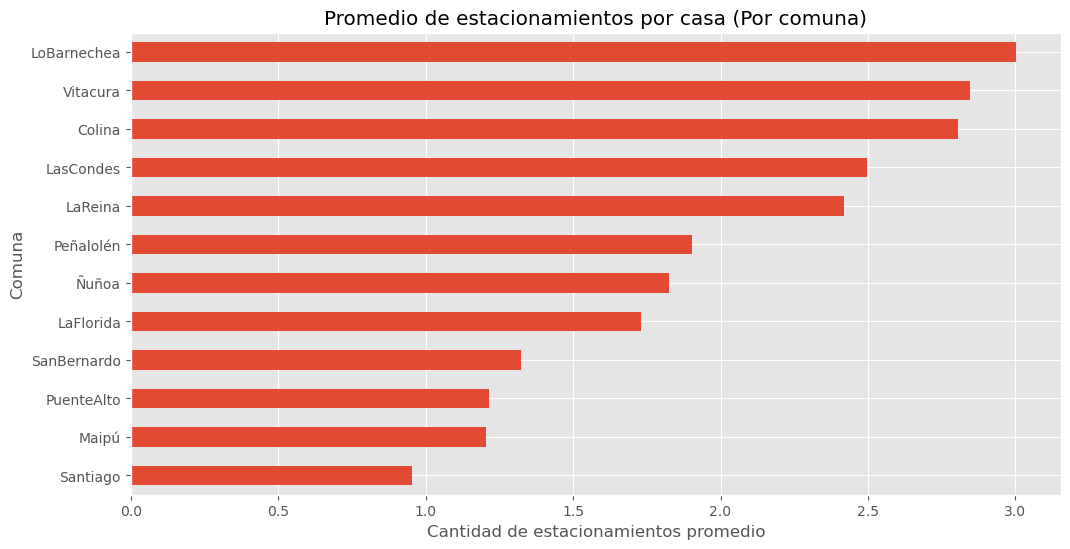

In [14]:
cx = df_clean.groupby('Comuna')['Parking'] \
    .agg(['mean', 'count']) \
    .query('count >= 250') \
    .sort_values('mean')['mean'] \
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio de estacionamientos por casa (Por comuna)'
    )

cx.set_xlabel('Cantidad de estacionamientos promedio')
cx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

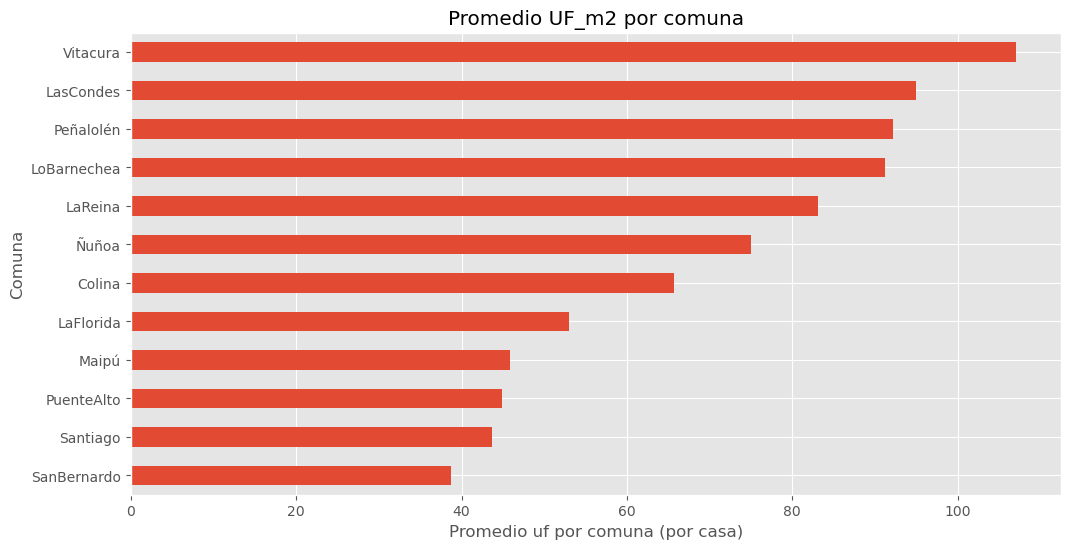

In [15]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area'])

dx = df_clean.groupby('Comuna')['UF_m2'] \
    .agg(['mean','count']) \
    .query('count > 250') \
    .sort_values('mean')['mean'] \
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio UF_m2 por comuna'
    )

dx.set_xlabel('Promedio uf por comuna (por casa)')
dx.set_ylabel('Comuna')

In [16]:
#corr = df_clean.drop(columns=['Comuna','id','Ubicacion','Realtor','Price_CLP','Price_USD']).corr()
corr = df_clean.select_dtypes('number').corr()
display(corr)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2
Price_UF,1.000000,0.393387,0.649385,-0.000218,0.056000,0.387746,0.141700
Dorms,0.393387,1.000000,0.599356,0.015142,0.024240,0.179043,0.020205
Baths,0.649385,0.599356,1.000000,0.004168,0.037898,0.327498,0.068115
Built Area,-0.000218,0.015142,0.004168,1.000000,0.020431,0.016659,-0.005870
Total Area,0.056000,0.024240,0.037898,0.020431,1.000000,0.037623,0.001961
Parking,0.387746,0.179043,0.327498,0.016659,0.037623,1.000000,0.028710
UF_m2,0.141700,0.020205,0.068115,-0.005870,0.001961,0.028710,1.000000


<Axes: >

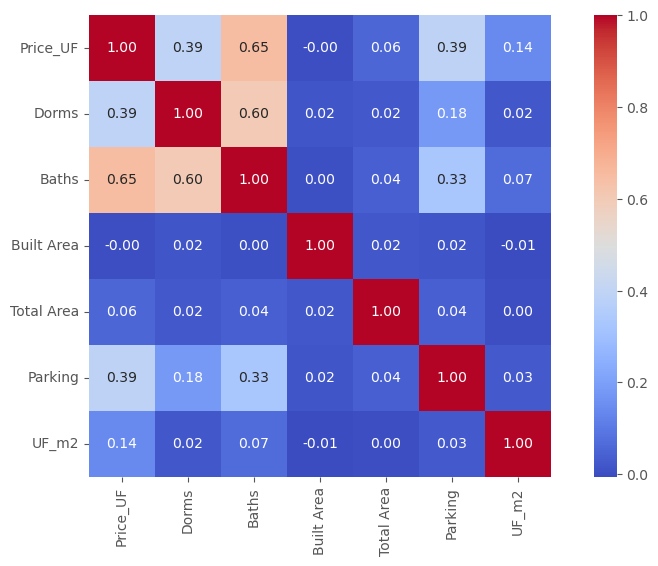

In [17]:
plt.figure(figsize=(11,6))
sns.heatmap(corr,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            annot=True)

# 5. ♾️ Identificacion de Outliers

In [18]:
(df_clean == 0).any()
df_clean = df_clean[df_clean['Parking'] != 0]

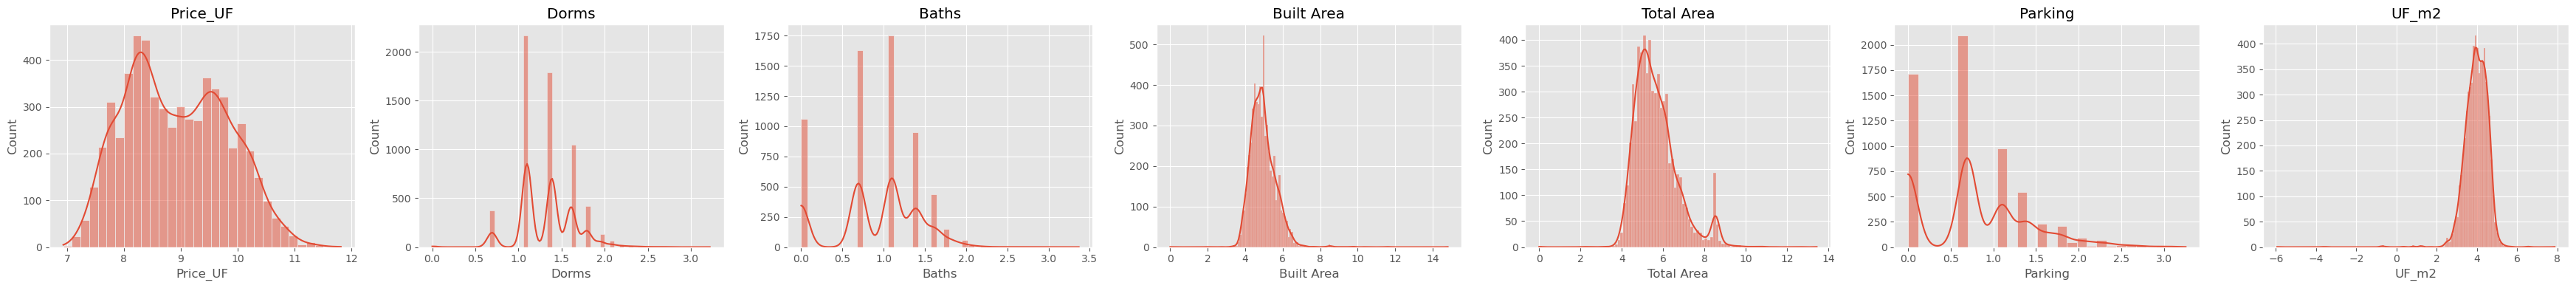

In [19]:
cols = df_clean.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols),4))
for i, col in enumerate(cols):
    sns.histplot(np.log(df_clean[col]), kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [22]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara = (serie < limite_inferior) | (serie > limite_superior)

    return mascara, limite_inferior, limite_superior

df_check = df_clean.drop(columns=['Comuna', 'Realtor'])
outlier_mask = pd.Series(False, index=df_check.index)

for name in df_check:
    mask_iqr, li, ls = detectar_outliers_iqr(df_check[name])
    print(f"Límites IQR para {name}:")
    print(f"Inferior: {li:.2f} | Superior: {ls:.2f}")
    print(f"Cantidad de outliers en {name} (IQR): {mask_iqr.sum()}\n")
    outlier_mask |= mask_iqr

Límites IQR para Price_UF:
Inferior: -13285.00 | Superior: 31971.00
Cantidad de outliers en Price_UF (IQR): 310

Límites IQR para Dorms:
Inferior: 0.00 | Superior: 8.00
Cantidad de outliers en Dorms (IQR): 64

Límites IQR para Baths:
Inferior: -1.00 | Superior: 7.00
Cantidad de outliers en Baths (IQR): 33

Límites IQR para Built Area:
Inferior: -82.50 | Superior: 377.50
Cantidad de outliers en Built Area (IQR): 454

Límites IQR para Total Area:
Inferior: -375.38 | Superior: 993.62
Cantidad de outliers en Total Area (IQR): 691

Límites IQR para Parking:
Inferior: -2.00 | Superior: 6.00
Cantidad de outliers en Parking (IQR): 302

Límites IQR para UF_m2:
Inferior: -23.60 | Superior: 140.13
Cantidad de outliers en UF_m2 (IQR): 75



In [23]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area']).round(2)
df_clean[outlier_mask]

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor,UF_m2
26,13500.0,IsladeMaipo,4.0,4.0,210.0,5000.0,2.0,Desconocido,64.29
53,20567.0,Colina,5.0,3.0,341.0,1099.0,2.0,Propital,60.31
95,14900.0,LaFlorida,5.0,6.0,240.0,600.0,7.0,Inmobiliaria Barrio Nuevo SpA,62.08
110,22800.0,Peñalolén,4.0,4.0,437.0,761.0,3.0,Desconocido,52.17
116,27000.0,LaFlorida,4.0,4.0,182.0,1600.0,5.0,Sp Rios Propiedades,148.35
...,...,...,...,...,...,...,...,...,...
8699,20900.0,LasCondes,4.0,4.0,239.0,1130.0,3.0,Easyprop,87.45
8703,29900.0,Vitacura,4.0,3.0,380.0,1016.0,2.0,Easyprop,78.68
8726,14990.0,Pudahuel,7.0,5.0,440.0,890.0,3.0,cclpropiedades,34.07
8743,105000.0,LasCondes,5.0,7.0,460.0,4925.0,8.0,Tsi Property,228.26


Agrupar por comunas, y ver el precio por m2 promedio

# TA PENDIENTE LA OPTIMIZACION, LO DEJO PA MAÑANA )HOY)